In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from matplotlib.colors import to_rgba
import subprocess


# Dataset directory
DATASET_DIR = Path("/Users/nedamohseni/Downloads/SoLo_dataset")

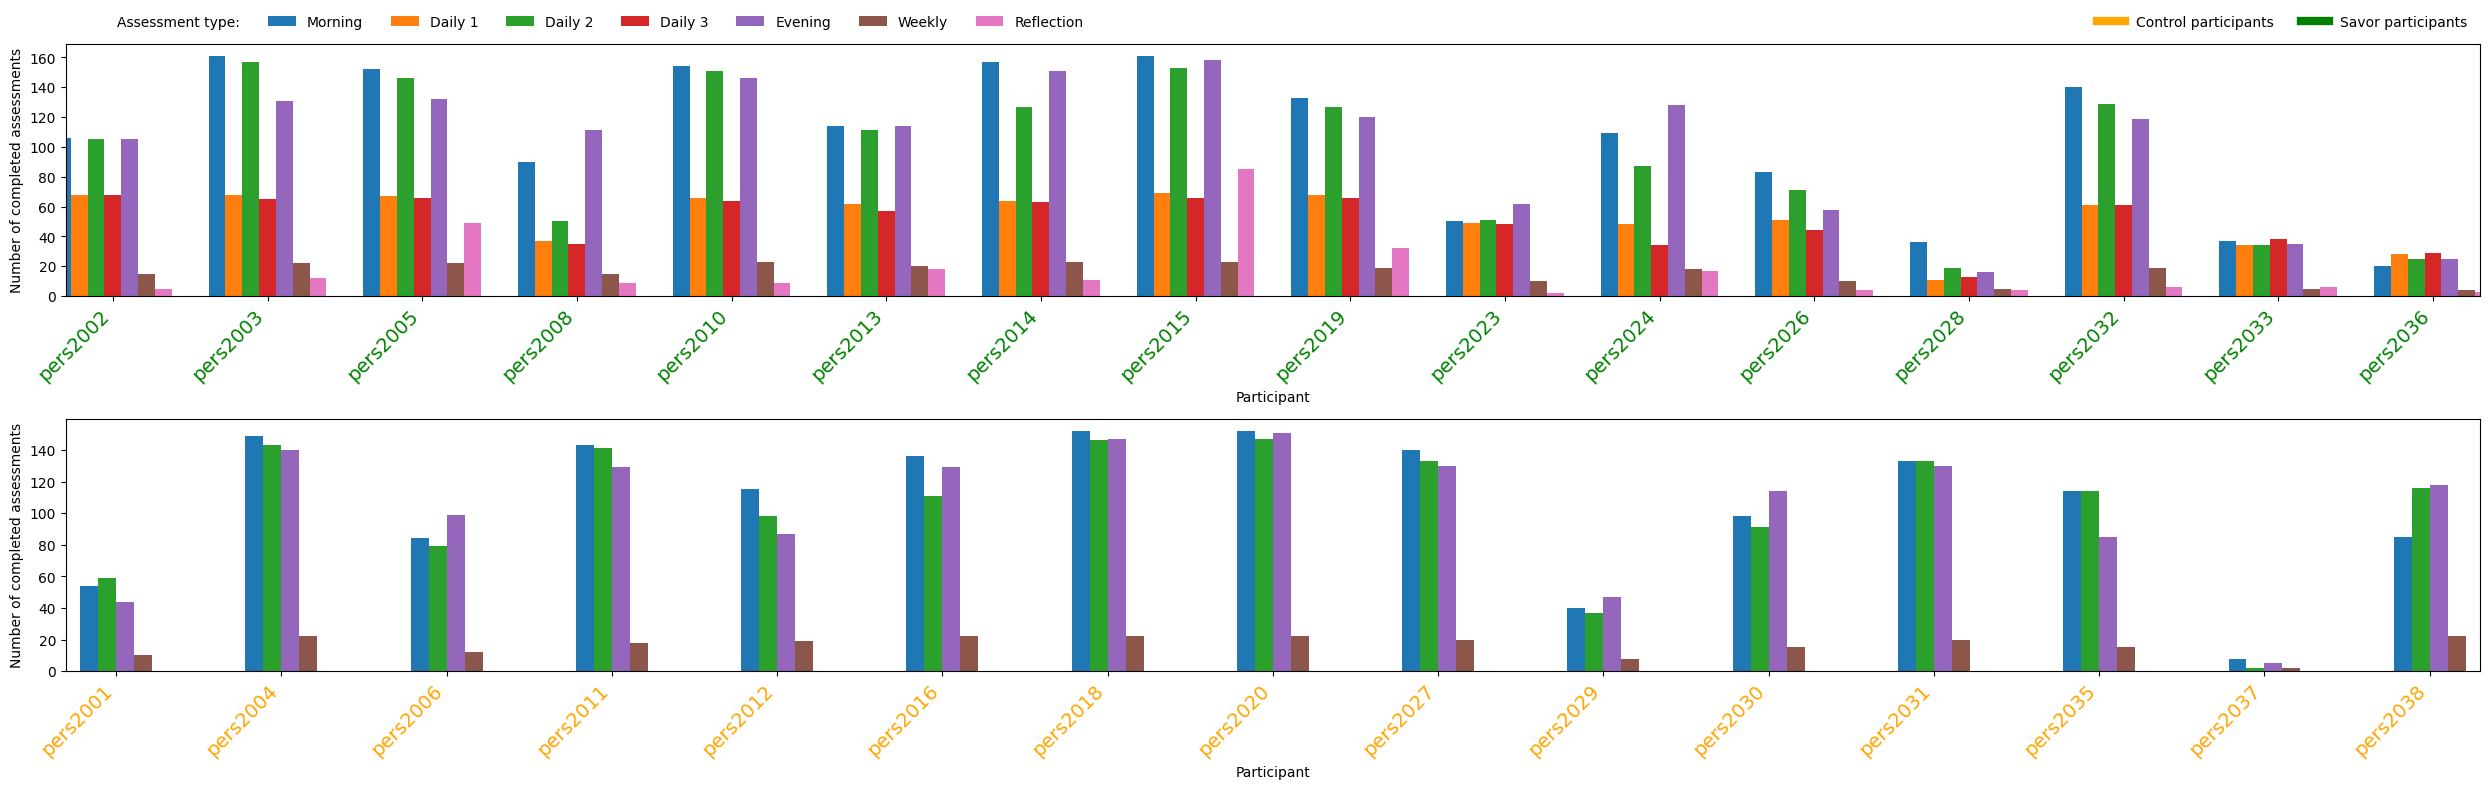

In [12]:
control = ["pers2001","pers2004","pers2006","pers2011","pers2012","pers2016","pers2018","pers2020","pers2027","pers2029","pers2030","pers2031","pers2035","pers2037","pers2038"]
savor = ["pers2002","pers2003","pers2005","pers2008","pers2010","pers2013","pers2014","pers2015","pers2019","pers2023","pers2024","pers2026","pers2028","pers2032","pers2033","pers2036"]
participants = control + savor

records = []

for participant_dir in sorted(DATASET_DIR.iterdir()):
    if not participant_dir.is_dir():
        continue
    participant = participant_dir.name
    self_report = participant_dir / "Self_Report"
    ema_path = self_report / "ema_daily.csv"
    weekly_path = self_report / "weekly_questionnaires.csv"
    reflection_path = self_report / "reflection_activity.csv"
    if ema_path.exists():
        ema = pd.read_csv(ema_path)
        ema_counts = ema["surveyindex"].value_counts()
        records.append({"participant": participant, "Morning": ema_counts.get(0, 0), "Daily 1": ema_counts.get(1, 0), "Daily 2": ema_counts.get(2, 0), "Daily 3": ema_counts.get(3, 0), "Evening": ema_counts.get(4, 0), "Weekly": len(pd.read_csv(weekly_path)) if weekly_path.exists() else 0, "Reflection": len(pd.read_csv(reflection_path)) if reflection_path.exists() else 0})

counts = pd.DataFrame(records).set_index("participant").reindex(participants, fill_value=0)

control_types = ["Morning", "Daily 2", "Evening", "Weekly"]
savor_types = ["Morning", "Daily 1", "Daily 2", "Daily 3", "Evening", "Weekly", "Reflection"]

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
assessment_colors = dict(zip(savor_types, colors))

# assessment_colors = {
#     "Morning": "#4E79A7",
#     "Daily 1": "#76B7B2",
#     "Daily 2": "#B07AA1",
#     "Daily 3": "#E15759",
#     "Evening": "#F28E2B",
#     "Weekly": "#7F7F7F",
#     "Reflection": "#EDC948"
# }

fig, axes = plt.subplots(2, 1, figsize=(25, 8))

ax = axes[0]
savor_counts = counts.loc[savor]
x = np.arange(len(savor_counts)) * 1.15
width = 0.125

for j, participant in enumerate(savor_counts.index):
    offsets = (np.arange(len(savor_types)) - (len(savor_types) - 1) / 2) * width
    for offset, assessment in zip(offsets, savor_types):
        ax.bar(x[j] + offset, savor_counts.loc[participant, assessment], width, color=assessment_colors[assessment])

ax.set_xlim(x[0] - 0.35, x[-1] + 0.35)
ax.set_xlabel("Participant")
ax.set_ylabel("Number of completed assessments")
ax.set_xticks(x)
ax.set_xticklabels(savor_counts.index, rotation=45, ha="right")
ax.tick_params(axis="x", labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_color("green")

legend1 = ax.legend(handles=[Patch(facecolor="none", edgecolor="none", label="Assessment type:")] + [Patch(facecolor=assessment_colors[a], label=a) for a in savor_types], frameon=False, loc="lower left", bbox_to_anchor=(0, 1.01), ncol=8)
ax.legend(handles=[Line2D([0], [0], color="orange", lw=6, label="Control participants"), Line2D([0], [0], color="green", lw=6, label="Savor participants")], frameon=False, loc="lower right", bbox_to_anchor=(1, 1.01), ncol=2)
ax.add_artist(legend1)

ax = axes[1]
control_counts = counts.loc[control]
x = np.arange(len(control_counts)) * 1.15
width = 0.125

for j, participant in enumerate(control_counts.index):
    offsets = (np.arange(len(control_types)) - (len(control_types) - 1) / 2) * width
    for offset, assessment in zip(offsets, control_types):
        ax.bar(x[j] + offset, control_counts.loc[participant, assessment], width, color=assessment_colors[assessment])

ax.set_xlim(x[0] - 0.35, x[-1] + 0.35)
ax.set_xlabel("Participant")
ax.set_ylabel("Number of completed assessments")
ax.set_xticks(x)
ax.set_xticklabels(control_counts.index, rotation=45, ha="right")
ax.tick_params(axis="x", labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_color("orange")

plt.tight_layout()
# plt.savefig("assessment_counts.png", dpi=300, bbox_inches="tight")
plt.show()

Participants: 31

Availability counts:
Calls                      6
Messages                  29
Notifications             29
Screen                    29
Touch                     27
Battery                   29
Device usage              29
Ambient noise             18
StudentLife audio         17
Application foreground    29
Mobility                  29
Oura activity             31
Oura sleep                31
Oura readiness            31
Raw PPG/HRM               29
HR/HRV features           29
dtype: int64


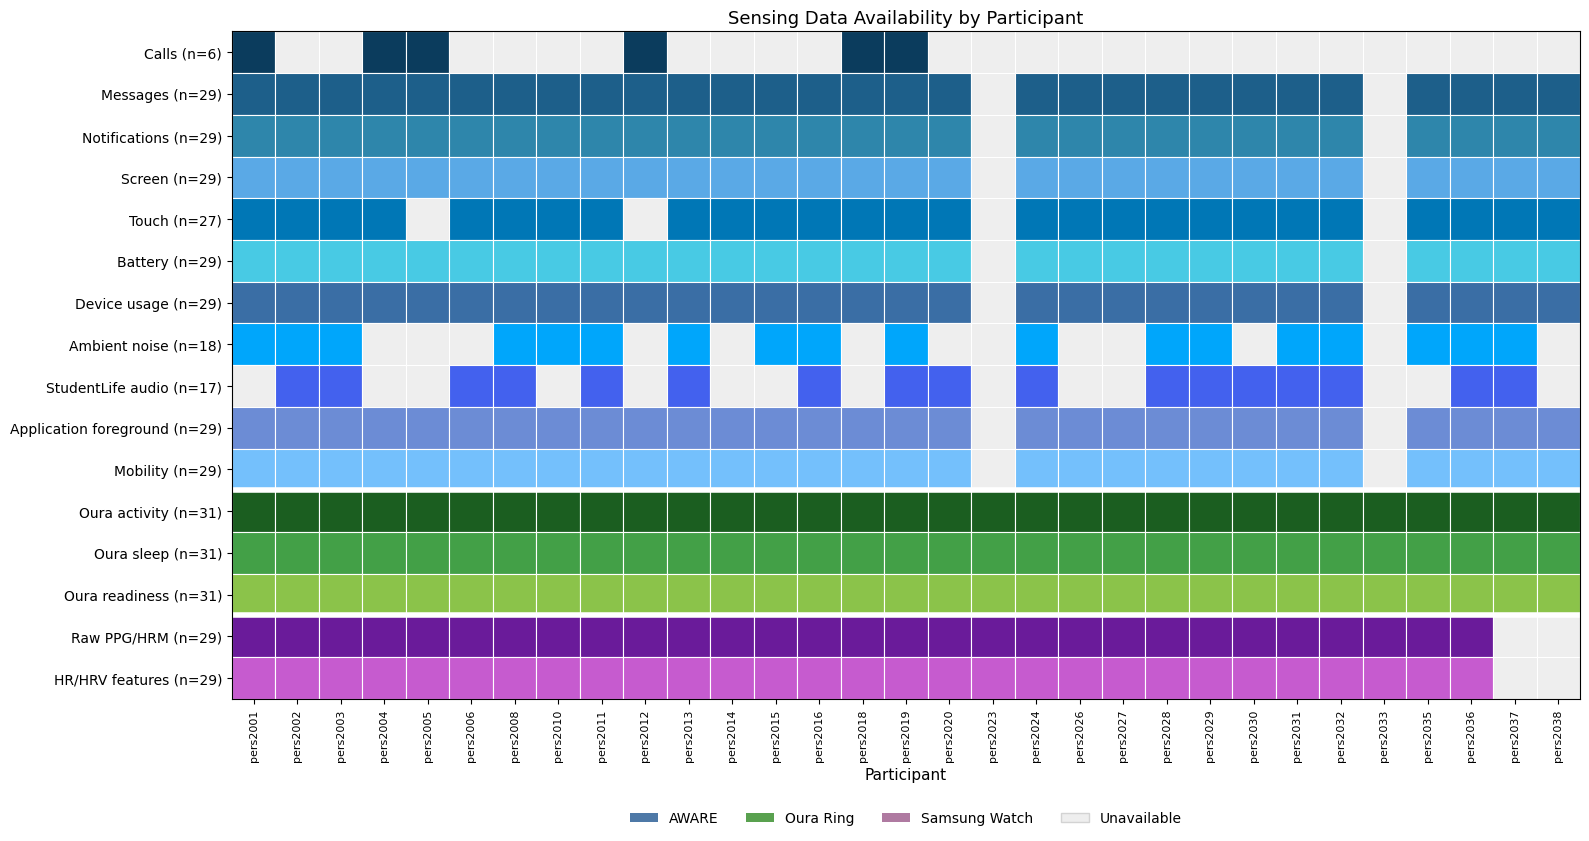

In [6]:
participant_dirs = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()], key=lambda x: x.name)

modalities = ["Calls", "Messages", "Notifications", "Screen", "Touch", "Battery", "Device usage", "Ambient noise", "StudentLife audio", "Application foreground", "Mobility", "Oura activity", "Oura sleep", "Oura readiness", "Raw PPG/HRM", "HR/HRV features"]

row_groups = {"Calls":"AWARE", "Messages":"AWARE", "Notifications":"AWARE", "Screen":"AWARE", "Touch":"AWARE", "Battery":"AWARE", "Device usage":"AWARE", "Ambient noise":"AWARE", "StudentLife audio":"AWARE", "Application foreground":"AWARE", "Mobility":"AWARE", "Oura activity":"Oura", "Oura sleep":"Oura", "Oura readiness":"Oura", "Raw PPG/HRM":"Samsung", "HR/HRV features":"Samsung"}

row_colors = {"Calls":"#0B3C5D", "Messages":"#1D5F8A", "Notifications":"#2E86AB", "Screen":"#5AA9E6", "Touch":"#0077B6", "Battery":"#48CAE4", "Device usage":"#3A6EA5", "Ambient noise":"#00A6FB", "StudentLife audio":"#4361EE", "Application foreground":"#6C8CD5", "Mobility":"#74C0FC", "Oura activity":"#1B5E20", "Oura sleep":"#43A047", "Oura readiness":"#8BC34A", "Raw PPG/HRM":"#6A1B9A", "HR/HRV features":"#C65BCF"}
group_legend_colors = {"AWARE":"#4E79A7", "Oura":"#59A14F", "Samsung":"#AF7AA1"}

unavailable_color = "#EEEEEE"

file_map = {"Calls":["AWARE/calls.csv"], "Messages":["AWARE/messages.csv"], "Notifications":["AWARE/notifications.csv"], "Screen":["AWARE/screen.csv"], "Touch":["AWARE/touch.csv"], "Battery":["AWARE/battery.csv"], "Device usage":["AWARE/device_usage.csv"], "Ambient noise":["AWARE/ambient_noise.csv"], "StudentLife audio":["AWARE/studentlife_audio.csv"], "Application foreground":["AWARE/applications_foreground.csv"], "Mobility":["AWARE/mobility_features.csv"], "Oura activity":["Oura/activity_1min.csv", "Oura/activity_5min.csv", "Oura/activity_daily.csv"], "Oura sleep":["Oura/sleep_5min.csv", "Oura/sleep_daily.csv"], "Oura readiness":["Oura/readiness_daily.csv"], "Raw PPG/HRM":["Samsung/raw_watch.csv"], "HR/HRV features":["Samsung/hrv_5min.csv"]}

def file_has_data(path): return path.exists() and path.is_file() and path.stat().st_size > 0

availability_df = pd.DataFrame(0, index=modalities, columns=[p.name for p in participant_dirs], dtype=int)

for participant_dir in participant_dirs:
    for modality in modalities:
        availability_df.loc[modality, participant_dir.name] = int(any(file_has_data(participant_dir / relative_path) for relative_path in file_map[modality]))

print("Participants:", len(participant_dirs))
print("\nAvailability counts:")
print(availability_df.sum(axis=1))

fig, ax = plt.subplots(figsize=(16, 8.5))

for i, modality in enumerate(availability_df.index):
    for j, participant in enumerate(availability_df.columns):
        color = row_colors[modality] if availability_df.iloc[i, j] == 1 else unavailable_color
        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor="white", linewidth=0.8))

ax.axhline(11, color="white", linewidth=4)
ax.axhline(14, color="white", linewidth=4)
4
ax.set_xlim(0, len(availability_df.columns))
ax.set_ylim(len(availability_df.index), 0)
ax.set_xticks(np.arange(len(availability_df.columns)) + 0.5)
ax.set_xticklabels(availability_df.columns, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(availability_df.index)) + 0.5)
ax.set_yticklabels([f"{modality} (n={int(availability_df.loc[modality].sum())})" for modality in availability_df.index], fontsize=10)
ax.set_xlabel("Participant", fontsize=11)
ax.set_ylabel("")
ax.set_title("Sensing Data Availability by Participant", fontsize=13)

legend_handles = [Patch(facecolor=group_legend_colors["AWARE"], label="AWARE"), Patch(facecolor=group_legend_colors["Oura"], label="Oura Ring"), Patch(facecolor=group_legend_colors["Samsung"], label="Samsung Watch"), Patch(facecolor=unavailable_color, edgecolor="lightgray", label="Unavailable")]

ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

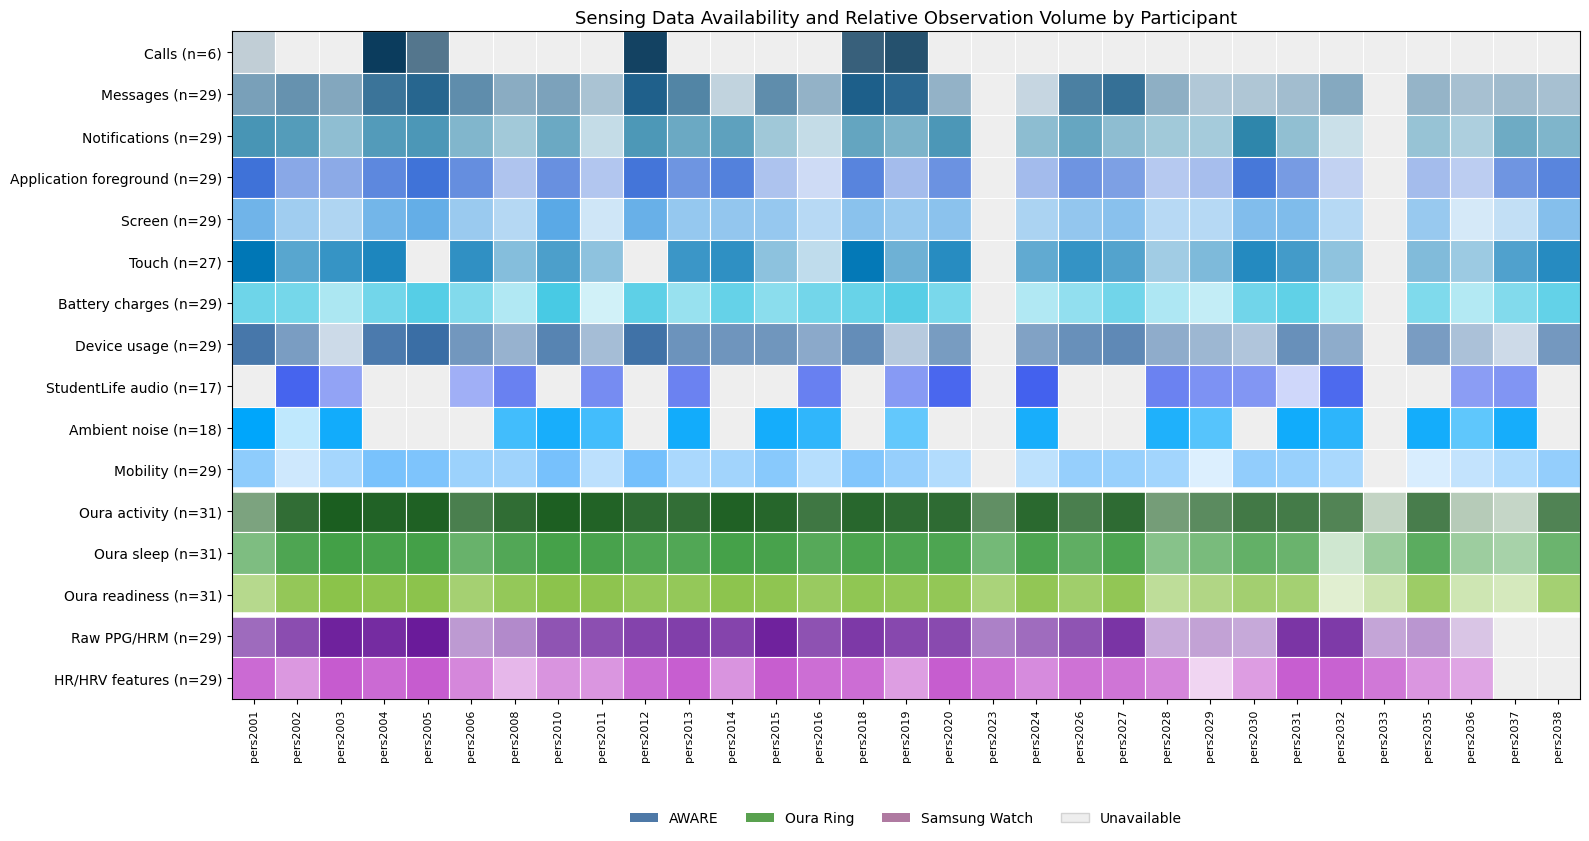

In [22]:
participant_dirs = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()], key=lambda x: x.name)

modalities = ["Calls", "Messages", "Notifications", "Application foreground", "Screen", "Touch", "Battery charges", "Device usage", "StudentLife audio", "Ambient noise", "Mobility", "Oura activity", "Oura sleep", "Oura readiness", "Raw PPG/HRM", "HR/HRV features"]
row_groups = {"Calls":"AWARE", "Messages":"AWARE", "Notifications":"AWARE", "Application foreground":"AWARE", "Screen":"AWARE", "Touch":"AWARE", "Battery charges":"AWARE", "Device usage":"AWARE", "StudentLife audio":"AWARE", "Ambient noise":"AWARE", "Mobility":"AWARE", "Oura activity":"Oura", "Oura sleep":"Oura", "Oura readiness":"Oura", "Raw PPG/HRM":"Samsung", "HR/HRV features":"Samsung"}
row_colors = {"Calls":"#0B3C5D", "Messages":"#1D5F8A", "Notifications":"#2E86AB", "Application foreground":"#3F72D8", "Screen":"#5AA9E6", "Touch":"#0077B6", "Battery charges":"#48CAE4", "Device usage":"#3A6EA5", "StudentLife audio":"#4361EE", "Ambient noise":"#00A6FB", "Mobility":"#74C0FC", "Oura activity":"#1B5E20", "Oura sleep":"#43A047", "Oura readiness":"#8BC34A", "Raw PPG/HRM":"#6A1B9A", "HR/HRV features":"#C65BCF"}
group_legend_colors = {"AWARE":"#4E79A7", "Oura":"#59A14F", "Samsung":"#AF7AA1"}
unavailable_color = "#EEEEEE"
file_map = {"Calls":["AWARE/calls.csv"], "Messages":["AWARE/messages.csv"], "Notifications":["AWARE/notifications.csv"], "Application foreground":["AWARE/applications_foreground.csv"], "Screen":["AWARE/screen.csv"], "Touch":["AWARE/touch.csv"], "Battery charges":["AWARE/battery.csv"], "Device usage":["AWARE/device_usage.csv"], "StudentLife audio":["AWARE/studentlife_audio.csv"], "Ambient noise":["AWARE/ambient_noise.csv"], "Mobility":["AWARE/mobility_features.csv"], "Oura activity":["Oura/activity_daily.csv"], "Oura sleep":["Oura/sleep_daily.csv"], "Oura readiness":["Oura/readiness_daily.csv"], "Raw PPG/HRM":["Samsung/raw_watch.csv"], "HR/HRV features":["Samsung/hrv_5min.csv"]}

def count_csv_rows(path): return max(int(subprocess.run(["wc", "-l", str(path)], capture_output=True, text=True).stdout.strip().split()[0]) - 1, 0) if path.exists() and path.is_file() else 0

count_df = pd.DataFrame(0, index=modalities, columns=[p.name for p in participant_dirs], dtype=float)

for participant_dir in participant_dirs:
    for modality in modalities:
        count_df.loc[modality, participant_dir.name] = sum(count_csv_rows(participant_dir / relative_path) for relative_path in file_map[modality])

availability_df = (count_df > 0).astype(int)
log_count_df = np.log1p(count_df)
normalized_df = pd.DataFrame(0.0, index=modalities, columns=availability_df.columns)

for modality in modalities:
    positive_log_values = log_count_df.loc[modality][count_df.loc[modality] > 0]
    row_min = positive_log_values.min() if len(positive_log_values) > 0 else 0
    row_max = positive_log_values.max() if len(positive_log_values) > 0 else 0
    normalized_df.loc[modality] = log_count_df.loc[modality].apply(lambda x: 0 if x == 0 else 1 if row_max == row_min else 0.25 + 0.75 * ((x - row_min) / (row_max - row_min)))

# print("\nRaw observation counts:")
# display(count_df.astype(int))
# print("\nLog-transformed observation counts:")
# display(log_count_df.round(2))

fig, ax = plt.subplots(figsize=(16, 8.5))

for i, modality in enumerate(availability_df.index):
    for j, participant in enumerate(availability_df.columns):
        alpha = normalized_df.iloc[i, j]
        color = to_rgba(row_colors[modality], alpha=alpha) if availability_df.iloc[i, j] == 1 else unavailable_color
        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor="white", linewidth=0.8))

ax.axhline(11, color="white", linewidth=4)
ax.axhline(14, color="white", linewidth=4)
ax.set_xlim(0, len(availability_df.columns))
ax.set_ylim(len(availability_df.index), 0)
ax.set_xticks(np.arange(len(availability_df.columns)) + 0.5)
ax.set_xticklabels(availability_df.columns, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(availability_df.index)) + 0.5)
ax.set_yticklabels([f"{modality} (n={int(availability_df.loc[modality].sum())})" for modality in availability_df.index], fontsize=10)
# ax.set_xlabel("Participant", fontsize=11)
ax.set_ylabel("")
ax.set_title("Sensing Data Availability and Relative Observation Volume by Participant", fontsize=13)

legend_handles = [Patch(facecolor=group_legend_colors["AWARE"], label="AWARE"), Patch(facecolor=group_legend_colors["Oura"], label="Oura Ring"), Patch(facecolor=group_legend_colors["Samsung"], label="Samsung Watch"), Patch(facecolor=unavailable_color, edgecolor="lightgray", label="Unavailable")]

ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

plt.tight_layout()
plt.show()